# 07 — Trade-Adjacent Production Analysis (GROW lens on supply-chain risk)

This notebook stays entirely within GROW data (QCL production + QI indices) but asks
**trade-flavored questions** — the kind a TRADE team would ask — so the two tracks
can be compared later without ever loading trade flows.

Two combined angles:
1. **Production concentration & supply-shock risk** — if world output of a crop sits
   in a few countries, global supply is fragile. Removing the top producer simulates
   a shock. (Production-side analogue of "supplier concentration".)
2. **Regional self-sufficiency gaps** — falling per-capita production means a region
   increasingly can't feed itself from its own output → rising structural import need.
   (A self-sufficiency proxy, no trade data required.)

Why this is defensible without trade data: production geography *is* the upstream of
trade. A concentrated crop is a global supply risk regardless of how it's shipped.

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.load import load_dataset
from src.clean import (standardize_columns, split_aggregates, resolve_china,
                       flag_item_aggregates)
from src.concentration import (production_shares, concentration_table, supply_shock,
                               combined_risk_table, per_capita_trend,
                               self_sufficiency_change)
from src.viz import save

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

## 1. Load QCL production, latest year, country-level individual commodities
Same cleaning discipline as notebook 02 — drop region aggregates, resolve China,
exclude item roll-ups so we rank real crops.

In [2]:
qcl = standardize_columns(load_dataset("QCL"))
prod = qcl[qcl["element"] == "Production"].copy()

latest = int(prod["year"].max())
counts = prod.groupby("year")["value"].count().tail(5)
year = latest if counts.get(latest, 0) >= 0.8 * counts.max() else latest - 1
print(f"Using year = {year}")

prod_y = prod[prod["year"] == year]
countries, region_aggs = split_aggregates(prod_y)
countries = resolve_china(countries)
countries = countries[~flag_item_aggregates(countries)].copy()
print(f"country-level commodity rows: {len(countries):,}")

[cache] QCL_long.parquet
Using year = 2024
country-level commodity rows: 13,055


## 2. Pick the crops to study
Start with the global top commodities + the staples from notebook 03, so the
concentration view covers what actually matters. Edit this list freely.

In [3]:
top_by_volume = (countries.groupby("item")["value"].sum()
                 .sort_values(ascending=False).head(15).index.tolist())
STUDY_CROPS = list(dict.fromkeys(["Wheat", "Rice", "Maize (corn)"] + top_by_volume))
STUDY_CROPS = [c for c in STUDY_CROPS if c in countries["item"].unique()]
print("Studying:", STUDY_CROPS)

Studying: ['Wheat', 'Rice', 'Maize (corn)', 'Sugar cane', 'Hen eggs in shell, fresh', 'Raw milk of cattle', 'Oil palm fruit', 'Soya beans', 'Potatoes', 'Cassava, fresh', 'Sugar beet', 'Tomatoes', 'Raw milk of buffalo', 'Meat, Poultry', 'Barley']


## 3. ANGLE 1 — Production concentration
Top-3 share and HHI per crop. HHI > 2500 ≈ "highly concentrated" (a global
supply-fragility flag). Ranked most→least concentrated.

In [4]:
conc = concentration_table(countries, STUDY_CROPS, year, n=3)
print("Production concentration (most fragile first):")
print(conc.to_string(index=False))

Production concentration (most fragile first):
                    item             top1_country  top1_share  top3_share    hhi  n_producers
     Raw milk of buffalo                    India       0.689       0.970 5434.0           22
          Oil palm fruit                Indonesia       0.581       0.865 3985.0           43
              Soya beans                   Brazil       0.363       0.783 2421.0          101
              Sugar cane                   Brazil       0.393       0.681 2186.0           93
            Maize (corn) United States of America       0.310       0.647 1694.0          161
                    Rice                    India       0.266       0.594 1528.0          114
Hen eggs in shell, fresh          China, mainland       0.358       0.528 1523.0          181
                Tomatoes          China, mainland       0.327       0.518 1356.0          166
                Potatoes          China, mainland       0.243       0.443  941.0          151
             

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/trade_adj_concentration_hhi.png


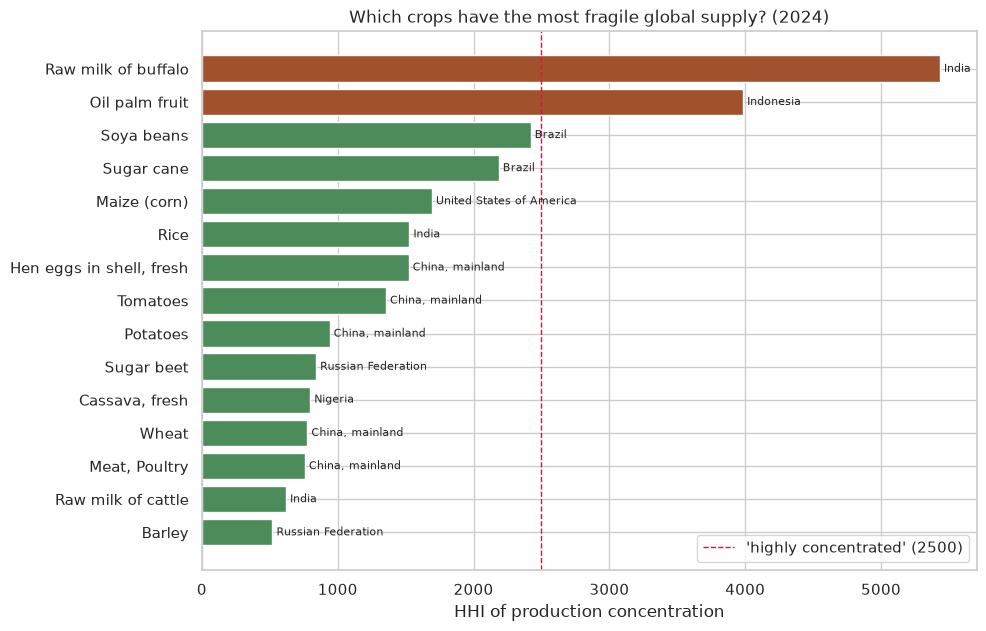

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))
c = conc.sort_values("hhi")
colors = ["#a0522d" if h > 2500 else "#4c8c5a" for h in c["hhi"]]
ax.barh(c["item"], c["hhi"], color=colors)
ax.axvline(2500, color="crimson", ls="--", lw=1, label="'highly concentrated' (2500)")
ax.set_xlabel("HHI of production concentration")
ax.set_title(f"Which crops have the most fragile global supply? ({year})")
for i, (h, t) in enumerate(zip(c["hhi"], c["top1_country"])):
    ax.text(h, i, f" {t}", va="center", fontsize=8)
ax.legend()
save(fig, "trade_adj_concentration_hhi")
plt.show()

## 4. ANGLE 1 — Supply-shock simulation
For each crop, how much of world supply disappears if the #1 producer is knocked out?
The production-side version of the TRADE shock case study.

In [6]:
risk = combined_risk_table(countries, STUDY_CROPS, year, n=3)
print("Combined risk (concentration + shock):")
print(risk[["item", "top1_country", "top1_share", "top3_share", "hhi",
            "shock_if_top1_lost_pct"]].to_string(index=False))

Combined risk (concentration + shock):
                    item             top1_country  top1_share  top3_share    hhi  shock_if_top1_lost_pct
     Raw milk of buffalo                    India       0.689       0.970 5434.0                    68.9
          Oil palm fruit                Indonesia       0.581       0.865 3985.0                    58.1
              Soya beans                   Brazil       0.363       0.783 2421.0                    36.3
              Sugar cane                   Brazil       0.393       0.681 2186.0                    39.3
            Maize (corn) United States of America       0.310       0.647 1694.0                    31.0
                    Rice                    India       0.266       0.594 1528.0                    26.6
Hen eggs in shell, fresh          China, mainland       0.358       0.528 1523.0                    35.8
                Tomatoes          China, mainland       0.327       0.518 1356.0                    32.7
                

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/trade_adj_supply_shock.png


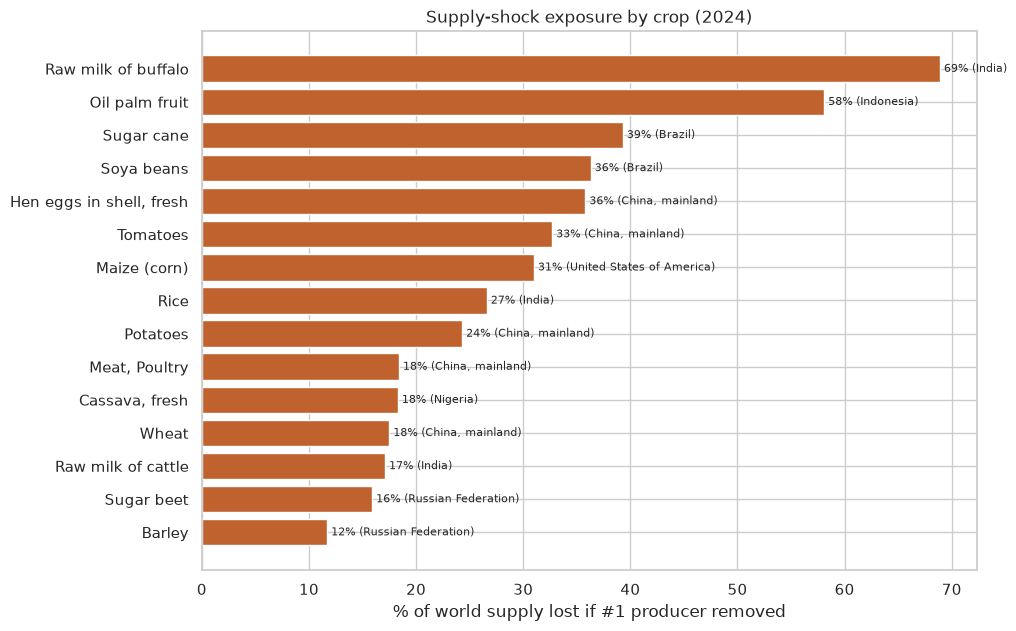

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))
r = risk.sort_values("shock_if_top1_lost_pct")
ax.barh(r["item"], r["shock_if_top1_lost_pct"], color="#c0622d")
ax.set_xlabel("% of world supply lost if #1 producer removed")
ax.set_title(f"Supply-shock exposure by crop ({year})")
for i, (v, t) in enumerate(zip(r["shock_if_top1_lost_pct"], r["top1_country"])):
    ax.text(v, i, f" {v:.0f}% ({t})", va="center", fontsize=8)
save(fig, "trade_adj_supply_shock")
plt.show()

## 5. Concentration over time — is global supply getting more or less fragile?
Track top-3 share across years for a few key staples. Rising = concentration
increasing = growing systemic risk (a strong, trend-based hypothesis).

figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/trade_adj_concentration_trend.png


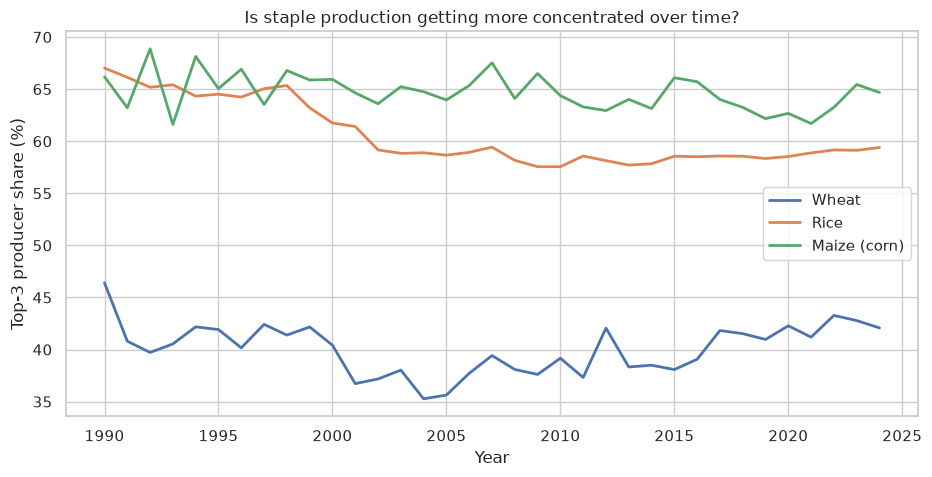

In [8]:
def conc_over_time(item, start=1990):
    yrs = sorted(y for y in prod["year"].unique() if y >= start)
    out = []
    for y in yrs:
        cy = split_aggregates(prod[prod["year"] == y])[0]
        cy = resolve_china(cy)
        cy = cy[~flag_item_aggregates(cy)]
        s = production_shares(cy, item, y)
        if len(s):
            out.append({"year": y, "top3_share": s.head(3).sum()})
    return pd.DataFrame(out)

fig, ax = plt.subplots(figsize=(11, 5))
for crop in ["Wheat", "Rice", "Maize (corn)"]:
    if crop in countries["item"].unique():
        t = conc_over_time(crop)
        ax.plot(t["year"], t["top3_share"] * 100, label=crop, linewidth=2)
ax.set_ylabel("Top-3 producer share (%)")
ax.set_xlabel("Year")
ax.set_title("Is staple production getting more concentrated over time?")
ax.legend()
save(fig, "trade_adj_concentration_trend")
plt.show()

## 6. ANGLE 2 — Regional self-sufficiency (QI per-capita production)
Falling per-capita production index = a region increasingly reliant on imports.
Uses QI aggregates (continents), no trade data.

In [9]:
qi = standardize_columns(load_dataset("QI"))
qi_countries, qi_aggs = split_aggregates(qi)

REGIONS = ["Africa", "Americas", "Asia", "Europe", "Oceania"]
ss = self_sufficiency_change(qi_aggs, REGIONS, span=10)
print("Per-capita production change over 10y (negative = losing self-sufficiency):")
print(ss.to_string(index=False))

[cache] QI_long.parquet
Per-capita production change over 10y (negative = losing self-sufficiency):
  region  latest_index  change_10y
  Africa         100.2        -0.4
    Asia         110.2        10.9
Americas         116.2        16.6
 Oceania         151.5        52.6
  Europe         164.4        68.7


figure -> /mnt/d/Sweta/Northeastern/Codes/python/wid-datathon-grow-eda/outputs/figures/trade_adj_self_sufficiency.png


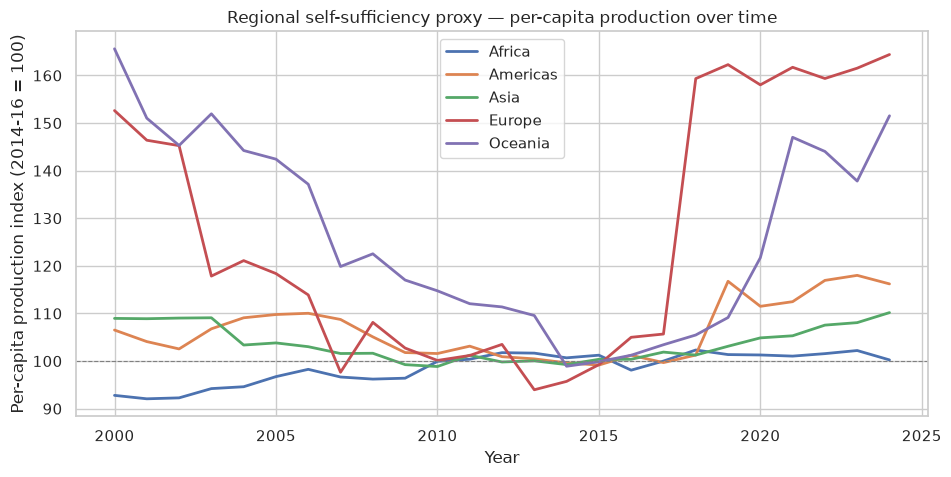

In [10]:
fig, ax = plt.subplots(figsize=(11, 5))
for region in REGIONS:
    s = per_capita_trend(qi_aggs, region)
    s = s[s.index >= 2000]
    if len(s):
        ax.plot(s.index, s.values, label=region, linewidth=2)
ax.axhline(100, color="grey", ls="--", lw=0.8)
ax.set_ylabel("Per-capita production index (2014-16 = 100)")
ax.set_xlabel("Year")
ax.set_title("Regional self-sufficiency proxy — per-capita production over time")
ax.legend()
save(fig, "trade_adj_self_sufficiency")
plt.show()

## 7. The bridge view — concentration × self-sufficiency
Crops that are BOTH globally concentrated AND consumed by regions with falling
per-capita production are the highest trade-risk staples: fragile supply meeting
rising import need. This is the money quadrant for a GROW→TRADE comparison.

**Checkpoint / synthesis feeds (add to notebook 06):**
- Most concentrated staple + who holds it (step 3–4) → global supply-fragility story.
- How concentration is trending (step 5) → is systemic risk rising?
- Which regions are losing self-sufficiency (step 6) → where import need is growing.
- Combined: a "production-side vulnerability" ranking that a TRADE team's
  import-side vulnerability score could be laid directly against — same countries,
  same crops, two lenses. Keep GROW standalone, but structured so the comparison is
  one join away if the team wants it.